In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

import numpy as np

np.random.seed(42)

warnings.filterwarnings("ignore")

DATA_PATH1 = "yellow_tripdata_2015-01.csv"
DATA_PATH2 = "yellow_tripdata_2016-01.csv"
DATA_PATH3 = "yellow_tripdata_2016-02.csv"
DATA_PATH4 = "yellow_tripdata_2016-03.csv"

# Partie 1 — Préparation des données

1. Charger un échantillon de 5 000 à 20 000 points.
2. Conserver uniquement :
   * latitude
   * longitude
3. Supprimer :
   * coordonnées nulles
   * coordonnées hors de NYC
4. Convertir les coordonnées en radians si nécessaire.

Question :
- Pourquoi la distance euclidienne classique n’est pas idéale pour des coordonnées GPS ? Indice : distance sphérique (Haversine).

  -> La Terre étant sphérique, la distance euclidienne n'est pas idéale pour calculer la distance entre deux coordonnées GPS éloignées.

In [2]:
df1 = pd.read_csv(DATA_PATH1)

sample_size = 10_000
sample = df1.sample(sample_size, random_state=42)

In [3]:
sample.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
3525802,1,2015-01-31 04:32:54,2015-01-31 04:36:41,1,1.30,-74.001579,40.736187,1,N,-74.008591,40.719151,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30
7798917,2,2015-01-29 07:26:35,2015-01-29 07:52:45,2,3.86,-73.967941,40.802380,1,N,-73.972244,40.761734,1,19.0,0.0,0.5,3.96,0.0,0.3,23.76
1176433,1,2015-01-25 10:48:44,2015-01-25 10:52:47,1,1.10,-73.990021,40.746696,1,N,-73.978386,40.758587,1,5.5,0.0,0.5,0.06,0.0,0.3,6.36
5005604,2,2015-01-01 17:16:07,2015-01-01 17:27:12,1,0.95,-73.987930,40.759708,1,N,-73.977608,40.753555,2,8.5,0.0,0.5,0.00,0.0,0.3,9.30
9954797,1,2015-01-05 22:08:12,2015-01-05 22:14:34,1,1.30,-73.988091,40.764626,1,N,-73.993050,40.748699,2,7.0,0.5,0.5,0.00,0.0,0.3,8.30


In [4]:
sample_gps = sample[["pickup_latitude", "pickup_longitude"]]

# Conversion radian
sample_gps["pickup_latitude"] = sample_gps["pickup_latitude"].apply(
    lambda x: x * np.pi / 180
)
sample_gps["pickup_longitude"] = sample_gps["pickup_longitude"].apply(
    lambda x: x * np.pi / 180
)

# On garde les points ayant des coordonnées GPS dans la ville de New York
sample_gps = sample_gps[
    (sample_gps["pickup_latitude"] > 0.70)
    & (sample_gps["pickup_latitude"] < 0.72)
    & (sample_gps["pickup_longitude"] > -1.294)
    & (sample_gps["pickup_longitude"] < -1.286)
]
print(f"Nombre de lignes supprimées : {sample_size - len(sample_gps)}")


Nombre de lignes supprimées : 189


In [5]:
sample_gps.describe()

,pickup_latitude,pickup_longitude
count,9811.000000,9811.000000
mean,0.711242,-1.291102
std,0.000473,0.000614
min,0.708689,-1.292971
25%,0.710995,-1.291403
50%,0.711290,-1.291225
75%,0.711537,-1.290984
max,0.714050,-1.287226


# Partie 2 — Compréhension des paramètres DBSCAN

1. Quelle unité doit avoir epsilon pour des coordonnées GPS ?

   -> $\epsilon$ doit être de l'ordre du millième ou inférieur.
2. Pourquoi min_samples doit être ajusté selon la densité urbaine ?

   -> Lorque la densité urbain est élevé, les points sont plus raprochés que lorsque la densité est faible. Sans ajustement du paramètre min_sample, on risque de ne construire aucun cluster dans les zones à faible densité ou de ne construire qu'un seul cluster dans les zones à forte densité.
3. Pourquoi la dimension (ici 2D) simplifie le choix des paramètres ?

   -> En réduisant la dimensionnalité, on réduit la variablité des points dans l'espace vectorielle des individus.

# Partie 3 — Choix d’epsilon

Méthode k-distance :

1. Calculer la distance au 4e ou 5e voisin.
2. Tracer la courbe triée.
3. Identifier le “coude”.
4. Justifier le choix d’epsilon.

Expliquer ce que représente physiquement epsilon (ex : 200 mètres).

-> L'epsilon correspond au rayon de voisinage. Un epsilon de 200m signifie que le voisinage des points sera de 200m, autrement dit les points situés à au plus 200m pourront être dans le même cluster.

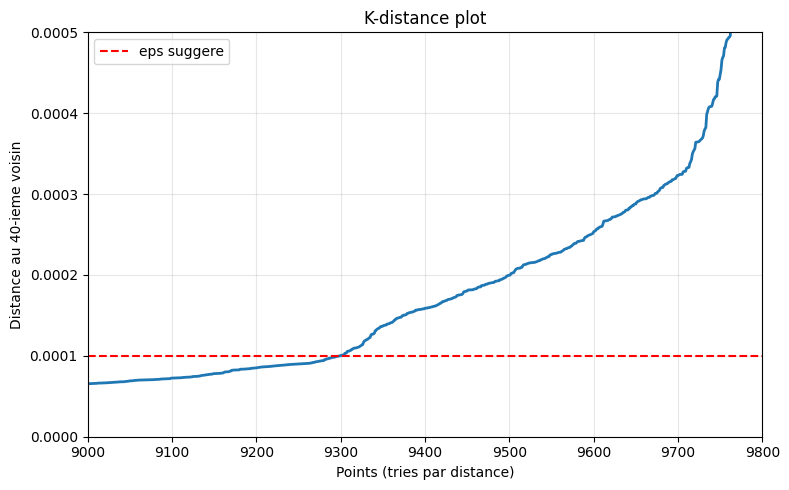

In [33]:
k = 40
nn = NearestNeighbors(n_neighbors=k)
nn.fit(sample_gps)
distances, indices = nn.kneighbors(sample_gps)

k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=2)
plt.xlabel("Points (tries par distance)")
plt.ylabel(f"Distance au {k}-ieme voisin")
plt.title("K-distance plot")
plt.grid(True, alpha=0.3)
plt.axhline(y=0.0001, color="r", linestyle="--", label="eps suggere")
plt.xlim(9000, 9800)
plt.ylim(0, 0.0005)

plt.legend()
plt.tight_layout()
plt.show()

$\epsilon\simeq 0.0001$

# Partie 4 — Application DBSCAN

1. Appliquer DBSCAN avec la métrique appropriée (euclidienne ou haversine).
2. Identifier :

   * nombre de clusters
   * nombre de points bruit
3. Visualiser les clusters sur une carte.

In [81]:
dbscan = DBSCAN(eps=0.0001, min_samples=18, metric="haversine")
# dbscan = DBSCAN(eps=0.000052, min_samples=160, metric="haversine")
y_pred = dbscan.fit_predict(sample_gps)

sample_cluster = sample_gps.copy()
sample_cluster["cluster"] = y_pred

n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
n_noise = list(y_pred).count(-1)
print(f"Clusters trouves : {n_clusters}")
print(f"Points de bruit : {n_noise}")

Clusters trouves : 6
Points de bruit : 228


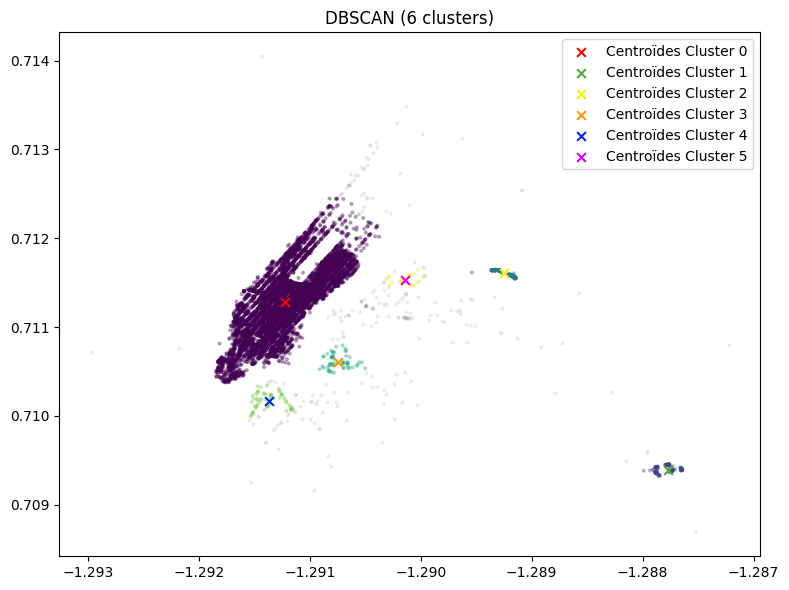

In [82]:
plt.figure(figsize=(8, 6))
plt.scatter(
    x=sample_cluster[sample_cluster["cluster"] != -1]["pickup_longitude"],
    y=sample_cluster[sample_cluster["cluster"] != -1]["pickup_latitude"],
    c=sample_cluster[sample_cluster["cluster"] != -1]["cluster"],
    cmap="viridis",
    s=4,
    alpha=0.3,
)
plt.scatter(
    x=sample_cluster[sample_cluster["cluster"] == -1]["pickup_longitude"],
    y=sample_cluster[sample_cluster["cluster"] == -1]["pickup_latitude"],
    color="gray",
    s=4,
    alpha=0.1,
)
centroides = sample_cluster[sample_cluster["cluster"] != -1].groupby("cluster").mean()
colors = ["#FF0000", "#49AC36", "#FFEE00", "#FF9900", "#0026FF", "#D400FF"]
for index, row in centroides.iterrows():
    plt.scatter(
        x=row["pickup_longitude"],
        y=row["pickup_latitude"],
        color=colors[index],
        marker="x",
        s=40,
        label=f"Centroïdes Cluster {index}",
    )

plt.title(f"DBSCAN ({n_clusters} clusters)")
plt.legend()

plt.tight_layout()
plt.show()

# Partie 5 — Interprétation métier

Pour chaque cluster :

1. Calculer le centre géographique.
2. Identifier la zone correspondante (ex : Manhattan Midtown, JFK Airport, etc.).
3. Interpréter :

   * zone résidentielle
   * zone touristique
   * zone aéroportuaire
   * zone d’affaires

In [83]:
centroides.head()

,pickup_latitude,pickup_longitude
cluster,,
0,0.711284,-1.291225
1,0.709396,-1.287768
2,0.711605,-1.289248
3,0.710612,-1.290743
4,0.710167,-1.291365


- Cluster 0 : Manhattan
- Cluster 1 : ?
- Cluster 2 : ?
- Cluster 3 : ?
- Cluster 4 : ?
- Cluster 5 : ?

# Partie 6 — Analyse avancée

1. Que se passe-t-il si epsilon est trop petit ?
2. Que se passe-t-il si epsilon est trop grand ?
3. Que se passe-t-il si min_samples augmente fortement ?
4. DBSCAN peut-il détecter des zones de densité très différentes ?
5. Proposer une alternative si les densités sont hétérogènes.